<a href="https://colab.research.google.com/github/Sanath-cmd/Internship_ITT/blob/main/KM_Cluster.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [64]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import scale
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score


In [65]:
data = pd.read_csv('/content/drive/MyDrive/Mall_Customers.csv')
data.columns
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [66]:
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]
X = scale(X)

In [67]:
wcss = []
for i in range(1,11):
  model = KMeans(n_clusters= i, random_state=42)
  model.fit(X)
  wcss.append(model.inertia_)

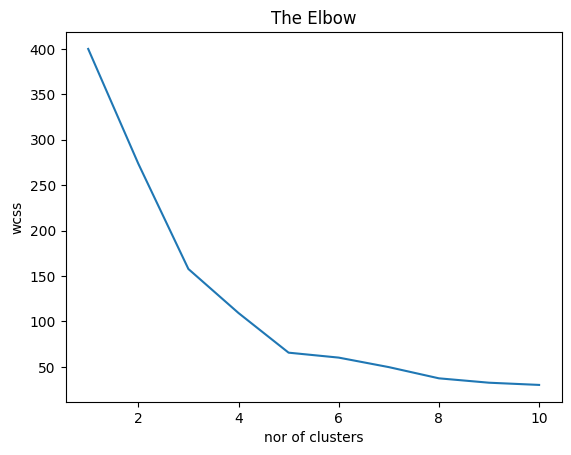

In [68]:
plt.plot(range(1,11), wcss)
plt.title("The Elbow")
plt.xlabel('nor of clusters')
plt.ylabel('wcss')
plt.show()
#from graph optimal k =5

In [69]:
model = KMeans(n_clusters = 5, random_state=42)
model.fit(X)
labels = model.labels_
data['Cluster'] = labels
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [70]:
score = silhouette_score(X, labels)
print(score)


0.5546571631111091


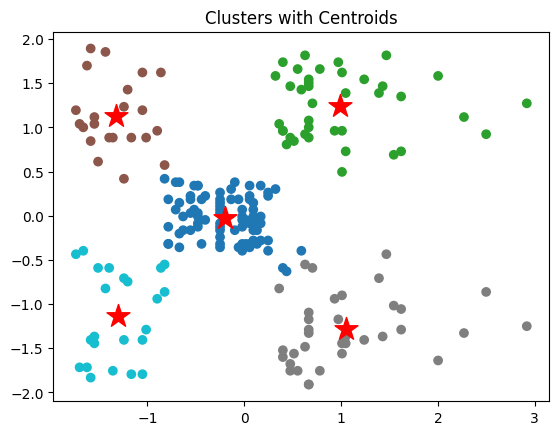

In [71]:
plt.scatter(X[:,0], X[:,1], c=model.labels_, cmap='tab10')
plt.scatter(model.cluster_centers_[:,0],
            model.cluster_centers_[:,1],
            s=300, c='red', marker='*')
plt.title("Clusters with Centroids")
plt.show()
